# Práctica 02. Exploración y preprocesamiento de datos de riesgo crediticio

**Autor:** Aldo Santiago Márquez  
**Asignatura:** Introducción a la Ciencia de Datos (ICD)  
**Fecha:** 4 de octubre de 2026

En esta práctica voy a trabajar con datos de clientes de tarjetas de crédito. Elegí este tema porque me interesa el sector fintech y quería analizar un problema relacionado con el riesgo de impago.

Primero reviso los datos y después aplico limpieza de categorías, extracción de características y PCA. La idea es ver qué cambia con cada técnica y qué puede servir para un análisis posterior. En esta práctica no entreno un modelo.

## 1. Contexto y procedencia

Usaré [Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients), de UCI. Tiene 30 000 clientes de Taiwán, 23 variables explicativas, un ID y el indicador de impago. El historial abarca de abril a septiembre de 2005 y los importes están en dólares de Taiwán (NT$).

Me interesa aprovechar esos seis meses para ver si puedo resumir el comportamiento de pago de los clientes. Lo planteo como una primera tarea de análisis para una startup de crédito, aunque los datos son antiguos y no representan necesariamente a una fintech mexicana actual.

El CSV original está incluido en el repositorio. La fuente lo publica con licencia [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

## 2. Carga de los datos

Cargo el CSV del repositorio. Si abro el notebook solo en Colab, se descarga de UCI.

In [1]:
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

SEMILLA = 42
colores = {"Sin impago": "#32847E", "Con impago": "#C76D55"}
orden_resultados = ["Sin impago", "Con impago"]

In [2]:
url_datos = "https://archive.ics.uci.edu/static/public/350/data.csv"
sha256_esperado = "45bcf4df62ff2e237a74eb155cabfb4bbbc171219a0637daef44fdad07503dd0"
rutas = [
    Path("datos/default_credit_card_clients.csv"),
    Path("Practicas/datos/default_credit_card_clients.csv"),
    Path("default_credit_card_clients.csv"),
]
ruta_local = next((ruta for ruta in rutas if ruta.is_file()), None)

if ruta_local is not None:
    contenido = ruta_local.read_bytes()
    print("Origen de la carga:", ruta_local)
else:
    with urlopen(url_datos, timeout=30) as respuesta:
        contenido = respuesta.read()
    print("Origen de la carga: CSV público de UCI")

sha256_obtenido = hashlib.sha256(contenido).hexdigest()
if sha256_obtenido != sha256_esperado:
    raise ValueError("El CSV difiere de la versión analizada. Usa la copia de Practicas/datos/.")

datos = pd.read_csv(BytesIO(contenido))
columnas_uci = ["ID"] + [f"X{i}" for i in range(1, 24)] + ["Y"]
columnas = [
    "ID", "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
] + [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)] + ["impago"]

if datos.columns.tolist() != columnas_uci:
    raise ValueError("Las columnas no coinciden con el CSV original de UCI.")

# Recupero los nombres descriptivos indicados por UCI; no cambio los valores.
df_original = datos.rename(columns=dict(zip(columnas_uci, columnas)))
df = df_original.copy()
df["resultado"] = df["impago"].map({0: "Sin impago", 1: "Con impago"})

estados_pago = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
facturas = [f"BILL_AMT{i}" for i in range(1, 7)]
pagos = [f"PAY_AMT{i}" for i in range(1, 7)]
variables_financieras = ["LIMIT_BAL"] + facturas + pagos

print(f"Registros: {len(df_original):,}")
print(f"Columnas originales: {df_original.shape[1]}")
print("Atributos explicativos:", df_original.shape[1] - 2)
print("Huella SHA-256 comprobada:", sha256_obtenido)
display(df_original.head())

Origen de la carga: Practicas\datos\default_credit_card_clients.csv
Registros: 30,000
Columnas originales: 25
Atributos explicativos: 23
Huella SHA-256 comprobada: 45bcf4df62ff2e237a74eb155cabfb4bbbc171219a0637daef44fdad07503dd0


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,impago
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


Cambié los nombres `X1` a `X23` por los de la ficha de UCI para que sea más fácil seguir el análisis. También agregué `resultado` para usar las etiquetas de impago en las gráficas.

| Variables | Qué contienen |
| --- | --- |
| `LIMIT_BAL` | Límite de crédito en NT$ |
| `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` | Datos demográficos |
| `PAY_0`, `PAY_2` a `PAY_6` | Estado de pago de septiembre a abril |
| `BILL_AMT1` a `BILL_AMT6` | Montos facturados de septiembre a abril, en NT$ |
| `PAY_AMT1` a `PAY_AMT6` | Pagos de septiembre a abril, en NT$ |
| `impago` | 0 = sin impago; 1 = con impago |

Hay que tener cuidado con los nombres: `PAY_0` corresponde a septiembre y `PAY_2` a agosto. Los sufijos no indican el mes del calendario.

## 3. Análisis exploratorio

### 3.1 Estructura y calidad

Empiezo revisando los tipos de datos, los faltantes y las filas repetidas.

In [3]:
estructura = pd.DataFrame({
    "Tipo": df_original.dtypes.astype(str),
    "Valores únicos": df_original.nunique(),
    "Faltantes": df_original.isna().sum(),
})
display(estructura)

print("Faltantes totales:", int(df_original.isna().sum().sum()))
print("Filas completamente duplicadas:", int(df_original.duplicated().sum()))
print("IDs repetidos:", int(df_original["ID"].duplicated().sum()))
print("Perfiles repetidos al omitir el ID:", int(df_original.drop(columns="ID").duplicated().sum()))

,Tipo,Valores únicos,Faltantes
ID,int64,30000,0
LIMIT_BAL,int64,81,0
SEX,int64,2,0
EDUCATION,int64,7,0
MARRIAGE,int64,4,0
AGE,int64,56,0
PAY_0,int64,11,0
PAY_2,int64,11,0
PAY_3,int64,11,0
PAY_4,int64,11,0


Faltantes totales: 0
Filas completamente duplicadas: 0
IDs repetidos: 0
Perfiles repetidos al omitir el ID: 35


No encontré faltantes ni IDs repetidos. Al quitar el ID aparecen 35 perfiles repetidos, pero los voy a conservar porque podrían pertenecer a clientes distintos.

Ahora reviso las categorías y algunos valores que llaman la atención.

In [4]:
for columna in ["SEX", "EDUCATION", "MARRIAGE", "PAY_0"]:
    print(f"\nFrecuencias de {columna}:")
    print(df_original[columna].value_counts().sort_index().to_string())

revision = pd.Series({
    "Educación fuera de códigos documentados (1 a 4)": (~df["EDUCATION"].isin([1, 2, 3, 4])).sum(),
    "Estado civil fuera de códigos documentados (1 a 3)": (~df["MARRIAGE"].isin([1, 2, 3])).sum(),
    "Límites de crédito no positivos": (df["LIMIT_BAL"] <= 0).sum(),
    "Edades no positivas": (df["AGE"] <= 0).sum(),
    "Clientes con alguna factura negativa": df[facturas].lt(0).any(axis=1).sum(),
    "Clientes con algún pago negativo": df[pagos].lt(0).any(axis=1).sum(),
})
display(revision.rename("Registros").to_frame())


Frecuencias de SEX:
SEX
1    11888
2    18112

Frecuencias de EDUCATION:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51

Frecuencias de MARRIAGE:
MARRIAGE
0       54
1    13659
2    15964
3      323

Frecuencias de PAY_0:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19


,Registros
Educación fuera de códigos documentados (1 a 4),345
Estado civil fuera de códigos documentados (1 a 3),54
Límites de crédito no positivos,0
Edades no positivas,0
Clientes con alguna factura negativa,1930
Clientes con algún pago negativo,0


En educación aparecen los códigos 0, 5 y 6, que la ficha de UCI no explica. Son 345 clientes. En estado civil pasa algo parecido con el código 0, presente en 54 clientes.

Los estados de pago también incluyen -2 y 0 sin explicación en esa ficha. Para contar atrasos usaré solo los valores positivos, que sí están descritos como meses de retraso.

También hay facturas negativas. No sé si corresponden a errores o a ajustes contables, así que las dejaré como están.

### 3.2 Distribución del impago

Primero quiero ver qué tan frecuente es el impago en este conjunto.

,Clientes,Porcentaje
resultado,,
Sin impago,23364,77.88
Con impago,6636,22.12


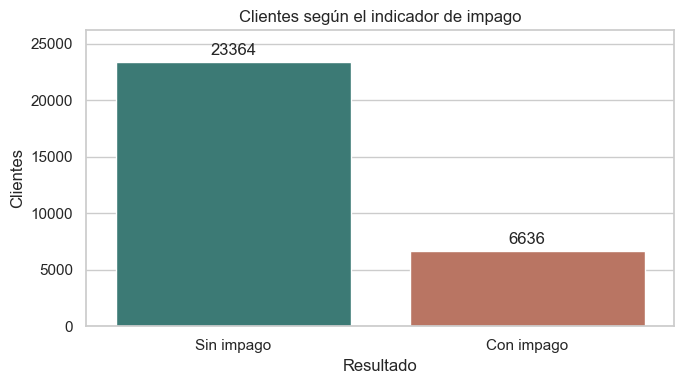

In [5]:
resumen_clases = (
    df["resultado"].value_counts().reindex(orden_resultados)
    .rename("Clientes").to_frame()
)
resumen_clases["Porcentaje"] = resumen_clases["Clientes"] / len(df) * 100
display(resumen_clases.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="resultado", hue="resultado", order=orden_resultados,
              hue_order=orden_resultados, palette=colores, legend=False, ax=ax)
ax.bar_label(ax.containers[0], padding=3)
ax.bar_label(ax.containers[1], padding=3)
ax.set(title="Clientes según el indicador de impago", xlabel="Resultado", ylabel="Clientes")
ax.margins(y=0.12)
plt.tight_layout()
plt.show()

El 22.12 % de los clientes tiene impago. Hay bastante más información de clientes sin impago, algo que tendría que considerar si después entreno un modelo.

### 3.3 Distribuciones y comparación entre clases

Reviso la edad y los importes, y comparo sus medianas entre clientes con y sin impago.

,count,mean,std,min,25%,50%,75%,99%,max
AGE,30000.0,35.49,9.22,21.0,28.00,34.0,41.0,60.00,79.0
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.0,500000.00,1000000.0
BILL_AMT1,30000.0,51223.33,73635.86,-165580.0,3558.75,22381.5,67091.0,350110.68,964511.0
PAY_AMT1,30000.0,5663.58,16563.28,0.0,1000.00,2100.0,5006.0,66522.18,873552.0


,AGE,LIMIT_BAL,BILL_AMT1,PAY_AMT1
resultado,,,,
Sin impago,34.0,150000.0,23119.5,2459.5
Con impago,34.0,90000.0,20185.0,1636.0


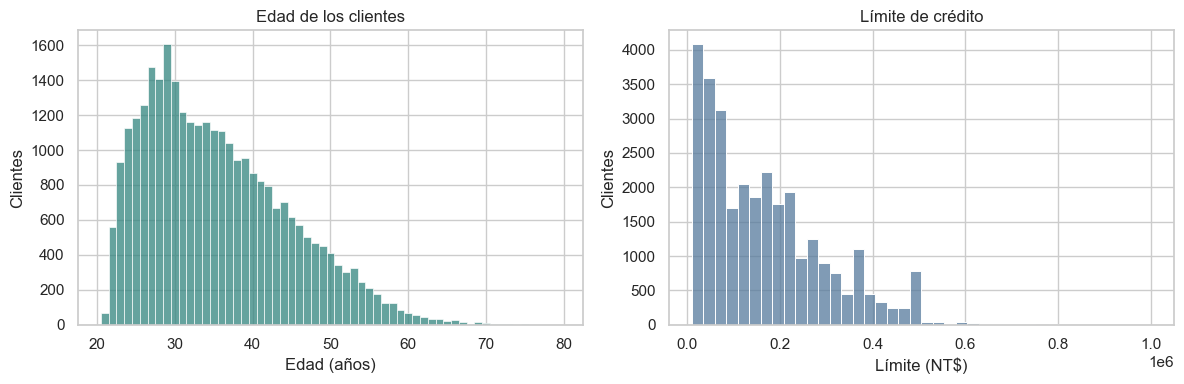

In [6]:
variables_resumen = ["AGE", "LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]
display(df[variables_resumen].describe(percentiles=[0.25, 0.5, 0.75, 0.99]).T.round(2))
display(df.groupby("resultado")[variables_resumen].median().reindex(orden_resultados))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="AGE", discrete=True, color="#32847E", ax=ax[0])
ax[0].set(title="Edad de los clientes", xlabel="Edad (años)", ylabel="Clientes")
sns.histplot(data=df, x="LIMIT_BAL", bins=40, color="#567A9C", ax=ax[1])
ax[1].set(title="Límite de crédito", xlabel="Límite (NT$)", ylabel="Clientes")
ax[1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
plt.tight_layout()
plt.show()

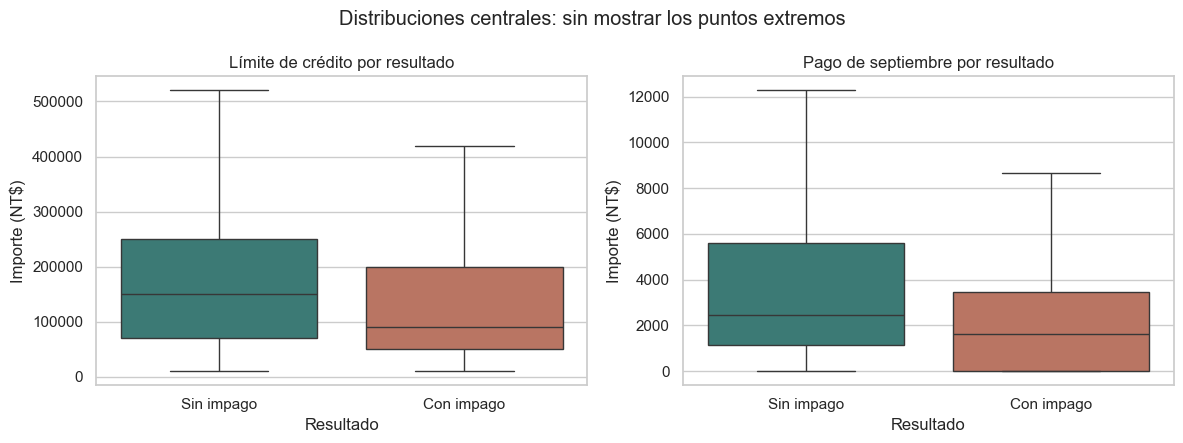

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for eje, columna, titulo in zip(
    ax, ["LIMIT_BAL", "PAY_AMT1"], ["Límite de crédito por resultado", "Pago de septiembre por resultado"]
):
    sns.boxplot(data=df, x="resultado", y=columna, hue="resultado",
                order=orden_resultados, hue_order=orden_resultados,
                palette=colores, legend=False, showfliers=False, ax=eje)
    eje.set(title=titulo, xlabel="Resultado", ylabel="Importe (NT$)")
fig.suptitle("Distribuciones centrales: sin mostrar los puntos extremos")
plt.tight_layout()
plt.show()

El límite de crédito se concentra en valores bajos y medios, con una cola hacia los más altos. Su promedio es de unos 167 484 NT$ y la mediana de 140 000 NT$. En los pagos también hay algunos importes muy grandes.

Los clientes con impago tienen una mediana de límite menor: 90 000 NT$, frente a 150 000 NT$ en los demás. También es menor su pago reciente. Por ahora, esto me da una primera diferencia entre los grupos.

En las cajas oculté los puntos extremos para ver mejor las distribuciones, pero no los eliminé de los datos.

### 3.4 Relación entre las mediciones financieras

Quiero ver si las facturas y los pagos de distintos meses se comportan de forma parecida. Para eso reviso sus correlaciones junto con el límite de crédito.

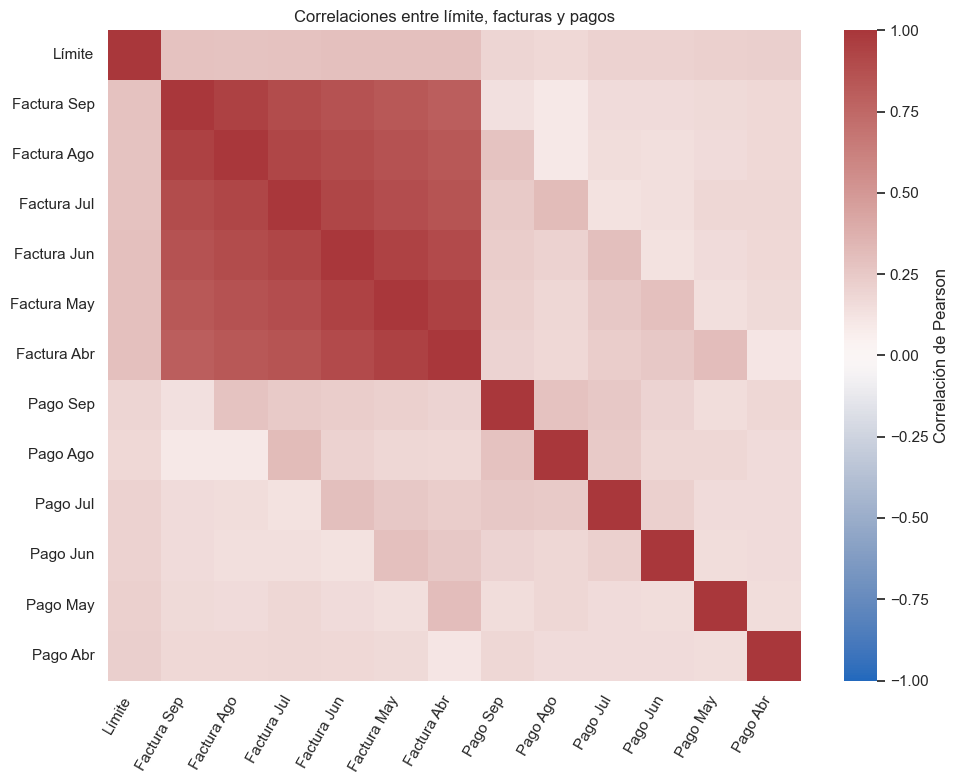

Correlación entre facturas de septiembre y agosto: 0.951


In [8]:
meses = ["Sep", "Ago", "Jul", "Jun", "May", "Abr"]
etiquetas_financieras = ["Límite"] + [f"Factura {mes}" for mes in meses] + [f"Pago {mes}" for mes in meses]
correlaciones = df[variables_financieras].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlaciones, cmap="vlag", center=0, vmin=-1, vmax=1,
            xticklabels=etiquetas_financieras, yticklabels=etiquetas_financieras,
            cbar_kws={"label": "Correlación de Pearson"}, ax=ax)
ax.set(title="Correlaciones entre límite, facturas y pagos")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()
print("Correlación entre facturas de septiembre y agosto:", round(df["BILL_AMT1"].corr(df["BILL_AMT2"]), 3))

Las facturas tienen correlaciones altas entre sí. Por ejemplo, septiembre y agosto llegan a 0.951. Los pagos no siguen un patrón tan uniforme. Esto me parece una buena razón para probar PCA y ver cuánto puedo resumir estas mediciones.

## 4. Técnica 1: limpieza de categorías

Voy a poner etiquetas a educación y estado civil. Los códigos que UCI no explica quedarán como `No documentado`; no los juntaré con `Otros`, porque no sé si significan lo mismo.

Esto hará más claras las categorías al revisar los resultados. Trabajo sobre una copia para conservar los códigos originales.

In [9]:
mapa_educacion = {1: "Posgrado", 2: "Universidad", 3: "Preparatoria", 4: "Otros"}
mapa_estado_civil = {1: "Casado/a", 2: "Soltero/a", 3: "Otros"}

df_limpio = df.copy()
df_limpio["EDUCATION"] = df["EDUCATION"].map(mapa_educacion).fillna("No documentado").astype("string")
df_limpio["MARRIAGE"] = df["MARRIAGE"].map(mapa_estado_civil).fillna("No documentado").astype("string")

trazabilidad = pd.DataFrame({
    "Código original": df_original["EDUCATION"],
    "Categoría después": df_limpio["EDUCATION"],
}).groupby(["Código original", "Categoría después"]).size().rename("Clientes").reset_index()
display(trazabilidad)

print("Filas antes:", len(df), "| después:", len(df_limpio))
print("Educación no documentada:", int(df_limpio["EDUCATION"].eq("No documentado").sum()))
print("Estado civil no documentado:", int(df_limpio["MARRIAGE"].eq("No documentado").sum()))

,Código original,Categoría después,Clientes
0,0,No documentado,14
1,1,Posgrado,10585
2,2,Universidad,14030
3,3,Preparatoria,4917
4,4,Otros,123
5,5,No documentado,280
6,6,No documentado,51


Filas antes: 30000 | después: 30000
Educación no documentada: 345
Estado civil no documentado: 54


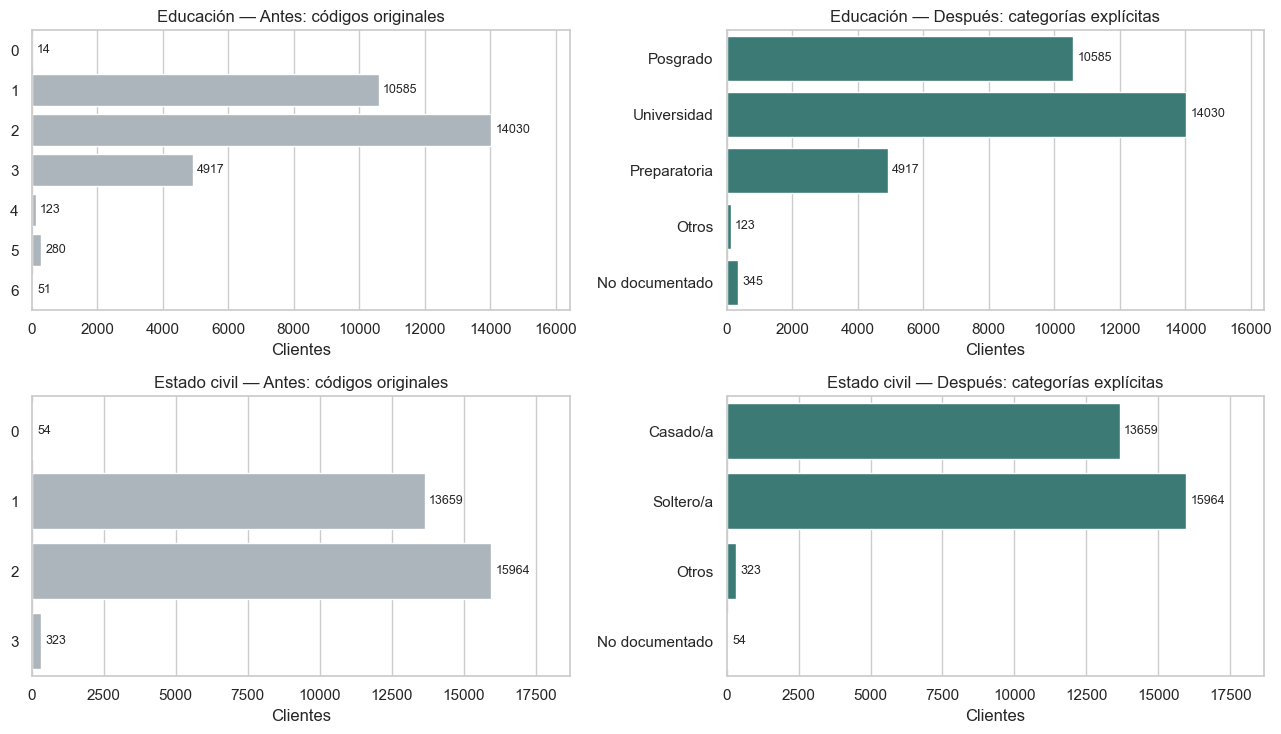

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7.5))
configuraciones = [
    ("EDUCATION", "Educación", ["Posgrado", "Universidad", "Preparatoria", "Otros", "No documentado"]),
    ("MARRIAGE", "Estado civil", ["Casado/a", "Soltero/a", "Otros", "No documentado"]),
]
for fila, (columna, nombre, orden) in enumerate(configuraciones):
    sns.countplot(data=df, y=columna, order=sorted(df[columna].unique()),
                  color="#AAB6BE", ax=ax[fila, 0])
    sns.countplot(data=df_limpio, y=columna, order=orden,
                  color="#32847E", ax=ax[fila, 1])
    limite = max(df[columna].value_counts().max(), df_limpio[columna].value_counts().max()) * 1.17
    for eje, etapa in zip(ax[fila], ["Antes: códigos originales", "Después: categorías explícitas"]):
        eje.set(title=f"{nombre} — {etapa}", xlabel="Clientes", ylabel="", xlim=(0, limite))
        eje.bar_label(eje.containers[0], padding=3, fontsize=9)
plt.tight_layout()
plt.show()

Educación pasa de siete códigos a cinco categorías. Los 345 casos con códigos 0, 5 y 6 quedan en `No documentado`, mientras que `Otros` conserva sus 123 casos. En estado civil cambia la etiqueta, pero sigue habiendo cuatro categorías.

Las gráficas ya se pueden leer sin consultar cada código. Aun así, el significado de los casos no documentados sigue pendiente; agruparlos no resuelve esa duda.

## 5. Técnica 2: extracción de características

### 5.1 Cantidad de meses con atraso

Creo `meses_con_atraso` contando cuántos de los seis estados mensuales son positivos. Así puedo distinguir entre un atraso aislado y uno que aparece en varios meses.

El resultado va de 0 a 6. Cuenta meses observados con atraso, no la duración total del retraso. Conservo las columnas originales porque el resumen pierde el orden y la gravedad de cada atraso.

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,meses_con_atraso
0,2,2,-1,-1,-2,-2,2
1,-1,2,0,0,0,2,2
2,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0
4,-1,0,-1,0,0,0,0
5,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0
7,0,-1,-1,0,0,-1,0


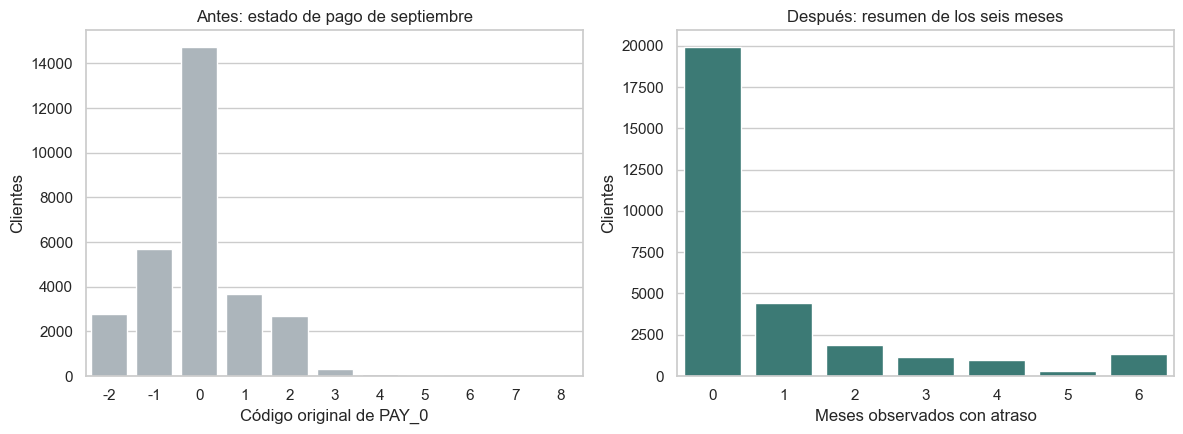

In [11]:
df_extraido = df_limpio.copy()
df_extraido["meses_con_atraso"] = df_extraido[estados_pago].gt(0).sum(axis=1)

display(df_extraido[estados_pago + ["meses_con_atraso"]].head(8))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df_limpio, x="PAY_0", order=sorted(df_limpio["PAY_0"].unique()),
              color="#AAB6BE", ax=ax[0])
ax[0].set(title="Antes: estado de pago de septiembre", xlabel="Código original de PAY_0", ylabel="Clientes")
sns.countplot(data=df_extraido, x="meses_con_atraso", order=range(7), color="#32847E", ax=ax[1])
ax[1].set(title="Después: resumen de los seis meses", xlabel="Meses observados con atraso", ylabel="Clientes")
plt.tight_layout()
plt.show()

Antes tenía el estado de cada mes por separado; ahora tengo un resumen del historial. La gráfica izquierda muestra septiembre y la derecha los seis meses, por lo que los valores de sus ejes significan cosas distintas.

En 19 931 clientes no aparece ningún mes con un estado positivo. La mayoría queda en ese grupo.

### 5.2 Monto facturado relativo al límite

Divido la factura de septiembre entre el límite de crédito para crear `facturado_relativo_limite`. Me interesa comparar cuánto representa la factura respecto a la línea de cada cliente, en lugar de mirar solo el importe.

Uso el monto facturado, así que la razón no equivale exactamente al uso actual del crédito.

,LIMIT_BAL,BILL_AMT1,facturado_relativo_limite
0,20000,3913,0.196
1,120000,2682,0.022
2,90000,29239,0.325
3,50000,46990,0.940
4,50000,8617,0.172
5,50000,64400,1.288
6,500000,367965,0.736
7,100000,11876,0.119


Razones negativas: 590
Razones mayores a uno: 2115
Razones faltantes: 0


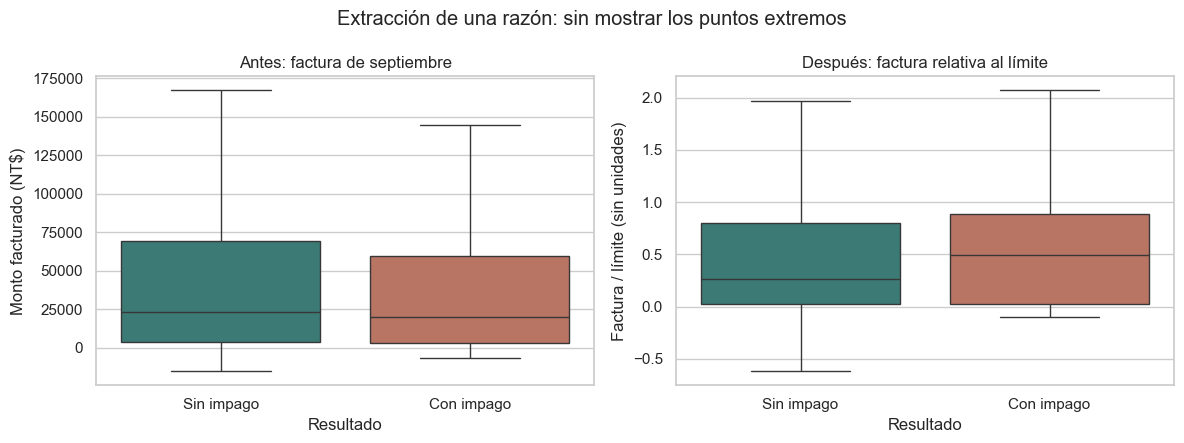

In [12]:
limite_valido = df_extraido["LIMIT_BAL"].where(df_extraido["LIMIT_BAL"] > 0)
df_extraido["facturado_relativo_limite"] = df_extraido["BILL_AMT1"] / limite_valido

display(df_extraido[["LIMIT_BAL", "BILL_AMT1", "facturado_relativo_limite"]].head(8).round(3))
print("Razones negativas:", int(df_extraido["facturado_relativo_limite"].lt(0).sum()))
print("Razones mayores a uno:", int(df_extraido["facturado_relativo_limite"].gt(1).sum()))
print("Razones faltantes:", int(df_extraido["facturado_relativo_limite"].isna().sum()))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for eje, columna, titulo, etiqueta in zip(
    ax,
    ["BILL_AMT1", "facturado_relativo_limite"],
    ["Antes: factura de septiembre", "Después: factura relativa al límite"],
    ["Monto facturado (NT$)", "Factura / límite (sin unidades)"],
):
    sns.boxplot(data=df_extraido, x="resultado", y=columna, hue="resultado",
                order=orden_resultados, hue_order=orden_resultados,
                palette=colores, legend=False, showfliers=False, ax=eje)
    eje.set(title=titulo, xlabel="Resultado", ylabel=etiqueta)
fig.suptitle("Extracción de una razón: sin mostrar los puntos extremos")
plt.tight_layout()
plt.show()

Aquí aparece una diferencia interesante. La factura mediana es menor entre los clientes con impago: 20 185 NT$, frente a 23 119.5 NT$ en los demás. Pero al compararla con el límite, la mediana de la razón es mayor: 0.493 frente a 0.267.

Mirar solo la factura en dinero ocultaba esa diferencia. Esta es la utilidad que le encuentro a la nueva variable.

Hay 590 razones negativas y 2 115 mayores a uno. Las conservo por la misma duda que encontré en las facturas. Como en las cajas anteriores, los puntos extremos no se muestran, pero siguen en los datos.

### 5.3 Meses con atraso e impago

Ahora comparo la nueva variable con el impago. Muestro también el tamaño de cada grupo para tener una referencia al leer los porcentajes.

,Clientes,Impagos,Porcentaje_impago
meses_con_atraso,,,
0,19931,2334,11.71
1,4426,1320,29.82
2,1899,736,38.76
3,1154,587,50.87
4,951,545,57.31
5,298,171,57.38
6,1341,943,70.32


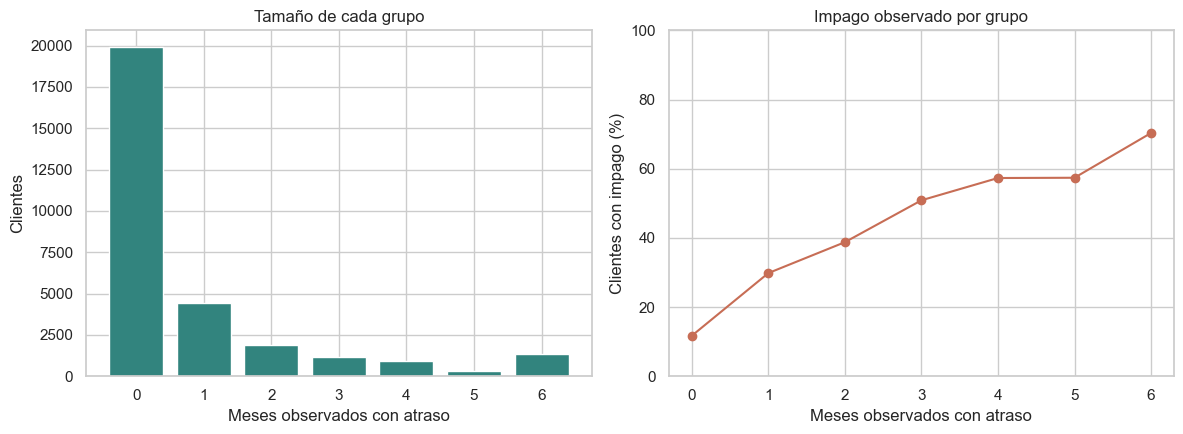

In [13]:
resumen_atrasos = df_extraido.groupby("meses_con_atraso").agg(
    Clientes=("ID", "size"),
    Impagos=("impago", "sum"),
    Porcentaje_impago=("impago", "mean"),
)
resumen_atrasos["Porcentaje_impago"] *= 100
display(resumen_atrasos.round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].bar(resumen_atrasos.index, resumen_atrasos["Clientes"], color="#32847E")
ax[0].set(title="Tamaño de cada grupo", xlabel="Meses observados con atraso", ylabel="Clientes")
ax[1].plot(resumen_atrasos.index, resumen_atrasos["Porcentaje_impago"], marker="o", color="#C76D55")
ax[1].set(title="Impago observado por grupo", xlabel="Meses observados con atraso", ylabel="Clientes con impago (%)", ylim=(0, 100))
for eje in ax:
    eje.set_xticks(range(7))
plt.tight_layout()
plt.show()

El porcentaje de impago aumenta de 11.7 % en el grupo sin meses con atraso a 70.3 % en el grupo con seis. El resumen sí muestra una relación que me interesaría estudiar después en un modelo.

Los grupos tienen tamaños muy distintos. Por ejemplo, el de cinco meses reúne solo 298 clientes. Además, incluso en el grupo sin atrasos hay impagos, así que no bastaría con esta variable para decidir a quién darle crédito.

## 6. Técnica 3: reducción de dimensionalidad con PCA

### 6.1 Preparación y ajuste

Por las correlaciones que encontré, aplicaré PCA al límite, las seis facturas y los seis pagos: 13 variables en total. No incluyo los códigos demográficos, el ID ni el impago. Tampoco agrego la razón que construí, porque usaría otra vez información de la factura y el límite.

Separo 80 % para entrenamiento y 20 % para prueba, manteniendo la proporción de impagos. Estandarizo los importes y ajusto el escalador y PCA solo con entrenamiento. Después aplico esas transformaciones a prueba. El EDA anterior sí usó el conjunto completo.

El escalado es necesario porque los importes tienen rangos distintos y [PCA no los estandariza automáticamente](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).

In [14]:
entrenamiento, prueba = train_test_split(
    df_extraido, test_size=0.20, stratify=df_extraido["impago"], random_state=SEMILLA
)

escalador = StandardScaler()
X_entrenamiento = escalador.fit_transform(entrenamiento[variables_financieras])
X_prueba = escalador.transform(prueba[variables_financieras])

# Ajusto todos los componentes para medir la varianza y después tomo los dos primeros.
pca = PCA(svd_solver="full")
pca.fit(X_entrenamiento)
componentes_prueba = pca.transform(X_prueba)

varianza = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)
n_componentes_90 = int(np.searchsorted(varianza_acumulada, 0.90) + 1)

print("Clientes para ajuste:", len(entrenamiento), "| clientes para transformación:", len(prueba))
print("Dimensiones en prueba antes:", X_prueba.shape, "| después:", componentes_prueba[:, :2].shape)
print("Varianza explicada por CP1 y CP2 (%):", np.round(varianza[:2] * 100, 2))
print("Varianza explicada acumulada con dos componentes (%):", round(varianza_acumulada[1] * 100, 2))
print("Componentes para alcanzar al menos 90 %:", n_componentes_90)

Clientes para ajuste: 24000 | clientes para transformación: 6000
Dimensiones en prueba antes: (6000, 13) | después: (6000, 2)
Varianza explicada por CP1 y CP2 (%): [45.62 13.59]
Varianza explicada acumulada con dos componentes (%): 59.21
Componentes para alcanzar al menos 90 %: 7


### 6.2 Comparación antes y después

Muestro los mismos 6 000 clientes de prueba. A la izquierda están el límite y la factura de septiembre; a la derecha, los dos componentes calculados con las 13 variables. Uso el impago como color para comparar los grupos.

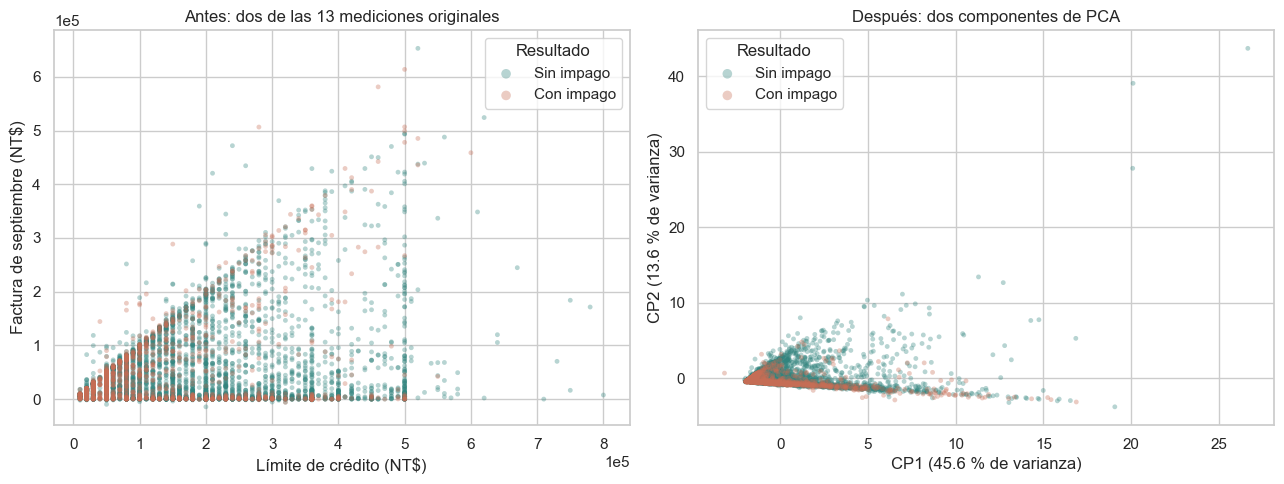

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for resultado in orden_resultados:
    mascara = prueba["resultado"].eq(resultado).to_numpy()
    ax[0].scatter(prueba.loc[mascara, "LIMIT_BAL"], prueba.loc[mascara, "BILL_AMT1"],
                  color=colores[resultado], label=resultado, s=12, alpha=0.35, edgecolors="none")
    ax[1].scatter(componentes_prueba[mascara, 0], componentes_prueba[mascara, 1],
                  color=colores[resultado], label=resultado, s=12, alpha=0.35, edgecolors="none")

ax[0].set(title="Antes: dos de las 13 mediciones originales", xlabel="Límite de crédito (NT$)", ylabel="Factura de septiembre (NT$)")
ax[0].ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
ax[1].set(title="Después: dos componentes de PCA", xlabel=f"CP1 ({varianza[0] * 100:.1f} % de varianza)", ylabel=f"CP2 ({varianza[1] * 100:.1f} % de varianza)")
for eje in ax:
    eje.legend(title="Resultado", markerscale=2)
plt.tight_layout()
plt.show()

Dos componentes conservan el 59.2 % de la varianza. Puedo dibujar las 13 variables en dos ejes, aunque se pierde una parte considerable de la variación.

Las clases siguen bastante mezcladas. PCA sirve para resumir los datos, pero aquí no veo una separación clara entre clientes con y sin impago. También hay puntos alejados del resto que influyen en esta vista.

### 6.3 Varianza explicada

Quiero ver cuántos componentes necesitaría para conservar más variación. Tomo 90 % como referencia para esta comparación.

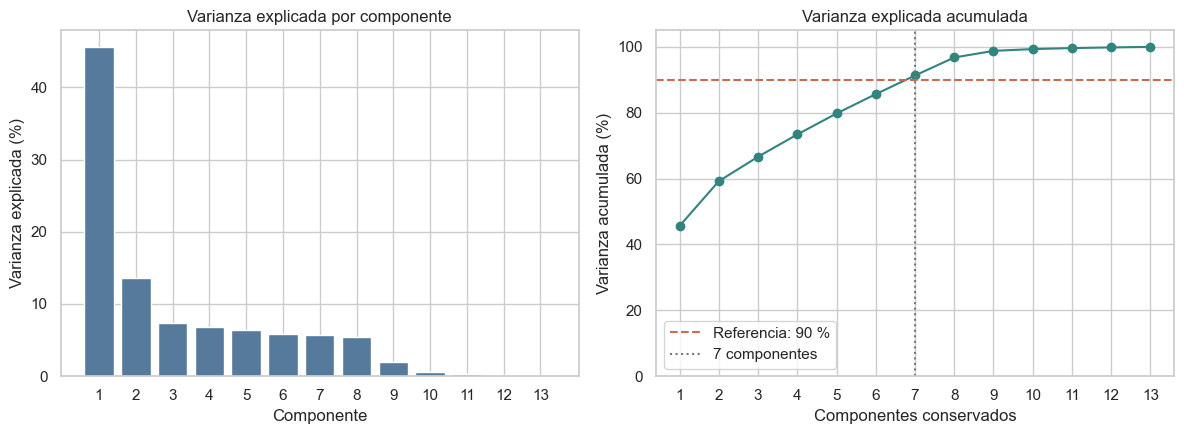

,CP1,CP2
Límite,0.164,0.283
Factura Sep,0.372,-0.186
Factura Ago,0.383,-0.173
Factura Jul,0.389,-0.139
Factura Jun,0.392,-0.113
Factura May,0.389,-0.101
Factura Abr,0.380,-0.098
Pago Sep,0.133,0.397
Pago Ago,0.123,0.422
Pago Jul,0.130,0.393


In [16]:
numeros = np.arange(1, len(varianza) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].bar(numeros, varianza * 100, color="#567A9C")
ax[0].set(title="Varianza explicada por componente", xlabel="Componente", ylabel="Varianza explicada (%)")
ax[1].plot(numeros, varianza_acumulada * 100, marker="o", color="#32847E")
ax[1].axhline(90, color="#C76D55", linestyle="--", label="Referencia: 90 %")
ax[1].axvline(n_componentes_90, color="#777777", linestyle=":", label=f"{n_componentes_90} componentes")
ax[1].set(title="Varianza explicada acumulada", xlabel="Componentes conservados", ylabel="Varianza acumulada (%)", ylim=(0, 105))
ax[1].legend()
for eje in ax:
    eje.set_xticks(numeros)
plt.tight_layout()
plt.show()

coeficientes = pd.DataFrame(pca.components_[:2].T, index=etiquetas_financieras, columns=["CP1", "CP2"])
display(coeficientes.round(3))

Hacen falta siete componentes para llegar al 90 %. Los dos primeros sirven para graficar, pero no me quedaría automáticamente con ellos para un modelo.

Al revisar los coeficientes, CP1 está más relacionado con las facturas y CP2 con varios de los pagos. Esto ayuda a entender un poco qué resume cada eje.

## 7. Comprobación final

Reviso que se hayan conservado los clientes y las mediciones, y que las variables nuevas queden dentro de lo esperado.

In [17]:
comprobaciones = pd.Series({
    "Mismos clientes después de limpieza y extracción": df_original["ID"].equals(df_extraido["ID"]),
    "Mediciones y objetivo conservados": df_original.drop(columns=["EDUCATION", "MARRIAGE"]).equals(
        df_extraido[df_original.drop(columns=["EDUCATION", "MARRIAGE"]).columns]
    ),
    "Meses con atraso dentro de 0 a 6": df_extraido["meses_con_atraso"].between(0, 6).all(),
    "Razones finitas con límites válidos": np.isfinite(df_extraido["facturado_relativo_limite"]).all(),
    "Clientes de entrenamiento y prueba separados": set(entrenamiento["ID"]).isdisjoint(prueba["ID"]),
    "PCA ajustado con 13 variables financieras": pca.n_features_in_ == 13,
    "Dos coordenadas por cliente de prueba": componentes_prueba[:, :2].shape == (len(prueba), 2),
    "Coordenadas finitas": np.isfinite(componentes_prueba).all(),
})
display(comprobaciones.rename("Se cumple").to_frame())
assert comprobaciones.all(), "Revisar las comprobaciones antes de continuar."

,Se cumple
Mismos clientes después de limpieza y extracción,True
Mediciones y objetivo conservados,True
Meses con atraso dentro de 0 a 6,True
Razones finitas con límites válidos,True
Clientes de entrenamiento y prueba separados,True
PCA ajustado con 13 variables financieras,True
Dos coordenadas por cliente de prueba,True
Coordenadas finitas,True


## 8. Conclusión

La limpieza se centró en las categorías, porque no había faltantes. Dejé identificados los casos que UCI no explica y conservé los valores originales para poder revisarlos después.

Lo más útil me pareció la extracción de características. Contar los meses con atraso permitió ver una relación con el impago, y dividir la factura entre el límite mostró una diferencia que no era tan clara al comparar solo los importes.

Con PCA pude resumir las mediciones financieras, aunque dos componentes conservaron solo el 59.2 % de la varianza y las clases siguieron mezcladas. Para conservar al menos el 90 % necesité siete componentes.

Si continuara este trabajo para una startup, probaría un modelo sencillo con y sin las variables nuevas. Por ahora tengo una preparación de los datos y algunas relaciones para investigar, no una regla para aprobar créditos. Como ya exploré todo el conjunto, buscaría datos nuevos para una evaluación posterior. Las relaciones observadas tampoco prueban causas.

## Referencias

Yeh, I. (2009). [Default of Credit Card Clients](https://doi.org/10.24432/C55S3H). UCI Machine Learning Repository. [Ficha del conjunto](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients), [CSV original](https://archive.ics.uci.edu/static/public/350/data.csv) y [licencia CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

Scikit-learn. Documentación de [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) y [fuga de información](https://scikit-learn.org/stable/common_pitfalls.html).

### Nota sobre el uso de inteligencia artificial

Usé Codex como apoyo para elegir el dataset, preparar y ejecutar el código y redactar las explicaciones. Tomé mis prácticas anteriores como referencia de estilo.